<div style="background-color:white; padding:20px; border-radius:10px;">

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ef/Sonatrach.svg/960px-Sonatrach.svg.png" 
       alt="Sonatrach Logo" width="220" height="220" style="object-fit:contain; margin:20px;"/>
  <img src="https://media.licdn.com/dms/image/v2/C4E0BAQG_4GF-XoONZA/company-logo_200_200/company-logo_200_200/0/1677775941269/ensia_higher_school_logo?e=2147483647&v=beta&t=EMa4YClTt5QCRdLNX_ozvVrgYgbiP4jUb-8NEnyTOEE" 
       alt="ENSIA Logo" width="220" height="220" style="object-fit:contain; margin:20px;"/>
</p>

<h1 align="center" style="color:#1E90FF; font-family:Arial;">
   🚀 Mini project: <span style="color:#FF4500;">Slug flow detection</span> in pipelines using <span style="color:#32CD32;">Machine Learning</span>
</h1>

</div>


---
---

# Introduction and Problem Statement

Multiphase flow occurs when gas and liquid phases are transported simultaneously in a pipeline. 
Depending on the operating conditions, different flow regimes may appear, such as bubble flow, stratified flow, annular flow, and intermittent or slug flow.  
Figure 1 illustrates a flow regime map for both vertical and horizontal gas–liquid mixtures.

---

## Slug Flow and Its Challenges

Among these regimes, **slug flow** is particularly problematic due to its unstable and cyclic nature. 
In this flow pattern, elongated liquid slugs alternate with large gas pockets, repeatedly filling the pipe cross-section.  
This behavior leads to pressure surges, mechanical vibrations, and irregular fluid delivery, all of which can reduce the performance, reliability, and safety of pipeline systems.

---

## Limitations of Traditional Approaches

Accurate prediction and detection of slug flow is essential for safe and efficient pipeline operation.  
Traditionally, this has been addressed through:

- Empirical models  
- Computational Fluid Dynamics (CFD)  

While valuable, these methods are often computationally expensive, data-specific, and unsuitable for real-time monitoring.

---

## Advances in AI for Slug Flow

Recent years have seen increasing interest in applying **Artificial Intelligence (AI)** and **Machine Learning (ML)** to study multiphase flow regimes.  
Approaches include:

- Machine learning classifiers trained on flow parameters  
- Computer vision techniques applied to flow images  
- Recurrent Neural Networks (RNNs) such as LSTM and GRU for time-series prediction  

Despite their promise, these methods face limitations related to data availability and quality:

- Image-based datasets are usually small, laboratory-controlled, and not representative of real-world conditions.  
- High-quality time-series datasets for slug detection are scarce, and most existing studies rely on simulated or in-house laboratory data.  

---

## Research Focus of This Project

To overcome these challenges, this project uses **Shoham’s flow pattern database (1982)**, a widely recognized benchmark in the two-phase flow community.  
The dataset allows slug flow detection to be formulated as a **classification task** rather than a prediction task, making it suitable for machine learning applications.  

The goals of this study are to:

- Develop AI-based models to classify slug and non-slug flow regimes.  
- Investigate the influence of key parameters, including **gas superficial velocity, liquid superficial velocity, pipe inclination, and pipe diameter**, on slug formation.  
- Compare the performance of different machine learning algorithms.  
- Analyze feature importance to highlight the most influential parameters.  

Through this approach, the project aims to demonstrate the potential of machine learning as a **practical and reliable tool** for rapid slug detection in multiphase flow systems.


---

---

# Shoham Dataset Exploration

The **Shoham dataset** is a widely used benchmark in multiphase flow research.  
It contains **5,675 experimental samples**, collected from controlled gas–liquid flow experiments, and is extensively referenced in flow pattern modeling studies.  

This dataset is particularly valuable because it provides the **key hydrodynamic parameters** that govern multiphase flow regimes.  
These parameters serve as the **input features** for machine learning models aimed at classifying different flow regimes.  

---

## Dataset Attributes

- **VSL (Liquid Superficial Velocity, m/s):** Velocity if liquid alone occupies the pipe cross-section.  
- **VSG (Gas Superficial Velocity, m/s):** Velocity if gas alone occupies the pipe cross-section.  
- **VISL (Liquid Viscosity, Pa·s):** Resistance of liquid to flow (thickness).  
- **VISG (Gas Viscosity, Pa·s):** Resistance of gas to flow.  
- **DENL (Liquid Density, kg/m³):** Mass per unit volume of liquid.  
- **DENG (Gas Density, kg/m³):** Mass per unit volume of gas.  
- **ST (Surface Tension, N/m):** Force at the gas–liquid interface.  
- **ANG (Pipe Inclination Angle, degrees):** 0° = horizontal, 90° = vertical, other = inclined.  
- **ID (Pipe Inner Diameter, m):** Internal diameter of the pipeline.  

---

## Flow Pattern Classes

The dataset classifies samples into **six main flow regimes**:

1. **DB (Dispersed Bubble Flow):** Many small bubbles uniformly distributed in the liquid.  
2. **SS (Stratified Smooth Flow):** Gas flows above liquid in distinct layers with a smooth interface.  
3. **SW (Stratified Wavy Flow):** Similar to SS but with a wavy gas–liquid interface.  
4. **A (Annular Flow):** Gas flows through the pipe core, while liquid forms a film along the walls.  
5. **I (Intermittent / Slug Flow):** Alternating liquid slugs and elongated gas bubbles.  
6. **B (Bubble Flow):** Larger spherical bubbles dispersed in liquid (less frequent than DB).  

---

This structured dataset allows us to **reformulate slug flow detection as a supervised classification problem**, where the goal is to learn from the given features to predict the correct flow regime.


## 1. Imports and Setup

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as colors
import seaborn as sns
sns.set(style='whitegrid',
        rc={'lines.linewidth': 2.5,
        'figure.figsize': (10, 8),
        'text.usetex': False,
        })

In [2]:
# Folder for saving figures
figures_path = './images' 
if not os.path.exists(figures_path):
    os.makedirs(figures_path) 

## 2. Load Dataset

In [3]:
# Load Dataset 
PATH = 'dataset/ShohamDB.csv' 
readdata = pd.read_csv(PATH) 
dataset = pd.read_csv(PATH, names=['Vsl', 'Vsg', 'VisL', 'VisG', 'DenL', 'DenG', 'ST', 'Ang', 'ID', 'Flow Pattern'], header=0)
# Summarize the Dataset 
print("shape of data =",dataset.shape) 
# Class Distribution 
print(dataset.groupby('Flow Pattern').size()) 

shape of data = (5675, 10)
Flow Pattern
A     1033
B      125
DB     594
I     2905
SS     140
SW     878
dtype: int64


## 3. Distribution of Flow Patterns (6 classes)

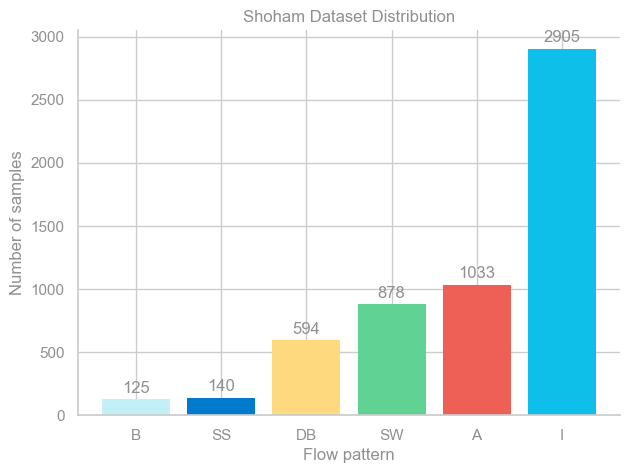

In [4]:
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#909090'
plt.rcParams['axes.labelcolor']= '#909090'
plt.rcParams['xtick.color'] = '#909090'
plt.rcParams['ytick.color'] = '#909090'
plt.rcParams['font.size']=12

cantidades = [125,  #B
              140,  #SS
              594,  #DB
              878,  #SW
              1033, #A
              2905  #I
              ]  

# nombres = ["B(Bubble Flow)","SS(Stratified Smooth Flow)","DB(Dispersed Bubble Flow)","SW(Stratified Wavy Flow)","A(Annular Flow)","I(Intermittent(Slug) Flow)"]
nombres = ["B","SS","DB","SW","A","I"]

color_palette_list = ['#C1F0F6','#007ACD',"#FFD97D","#60D394","#EE6055",'#0EBFE9']

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(nombres, cantidades, color=color_palette_list, edgecolor='none')

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 30,
            f'{height}', ha='center', va='bottom', color="#909090")

ax.set_ylabel("Number of samples")
ax.set_xlabel("Flow pattern")
ax.set_title("Shoham Dataset Distribution", color="#909090")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figures_path+"/data_distribution_SHOHAM_bar.pdf", bbox_inches="tight")
plt.show()


# Dataset Observation and Class Imbalance

The Shoham dataset consists of **5,675 labeled samples** distributed across six flow pattern classes:

- **DB**: Dispersed Bubble Flow  
- **SS**: Stratified Smooth Flow  
- **SW**: Stratified Wavy Flow  
- **A**: Annular Flow  
- **I**: Intermittent / Slug Flow  
- **B**: Bubble Flow  

---

## Class Distribution

An important challenge with this dataset is the **severe class imbalance**.  
As shown in Figure 2 (class distribution plot):

- The **slug flow class (`I`)** is heavily overrepresented.  
- Other classes, such as **B** and **SS**, contain far fewer samples.  

This imbalance can negatively affect machine learning models, causing them to favor the majority class while neglecting underrepresented ones.

---

## Reformulation into a Binary Task

Since the primary objective of this project is **slug flow detection**, we reformulated the classification problem as **binary**:

- **Slug Flow → class `I`**  
- **Non-Slug Flow → all other classes combined (`DB`, `SS`, `SW`, `A`, `B`)**  

This approach simplifies the task, reduces the effects of imbalance, and ensures the model directly targets the detection of slug flow events.


## 4. Transform to Binary Classification (Slug vs Non-slug)

In Shoham’s dataset:
- Slug = Intermittent Flow (I)
- Non-slug = all others {B, SS, DB, SW, A}

In [5]:
# Create binary column: 1 = Slug (I), 0 = Non-slug
dataset['Slug'] = dataset['Flow Pattern'].apply(lambda x: 1 if x == 'I' else 0)

# Count distribution
binary_counts = dataset['Slug'].value_counts().sort_index()
print(binary_counts)

# Labels for plotting
binary_labels = ['Non-slug', 'Slug']
binary_values = [binary_counts[0], binary_counts[1]]
binary_colors = ['#007ACD', '#EE6055']


Slug
0    2770
1    2905
Name: count, dtype: int64


## 5. Distribution of Slug vs Non-slug

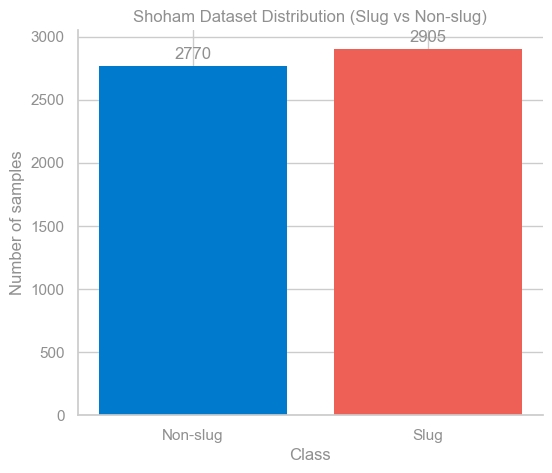

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(binary_labels, binary_values, color=binary_colors, edgecolor='none')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 30,
            f'{height}', ha='center', va='bottom', color="#909090")

ax.set_ylabel("Number of samples")
ax.set_xlabel("Class")
ax.set_title("Shoham Dataset Distribution (Slug vs Non-slug)", color="#909090")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figures_path+"/data_distribution_SHOHAM_binary.pdf", bbox_inches="tight")
plt.show()


**Observation:**  
The figure shows the new distribution after transforming the dataset into a binary classification task.  
Unlike the original multiclass setting, the classes are now **balanced** between **slug (`I`)** and **non-slug (`DB`, `SS`, `SW`, `A`, `B`)**, making the dataset more suitable for training reliable binary classifiers.


---
---

# Feature Selection

## 1. Check correlations

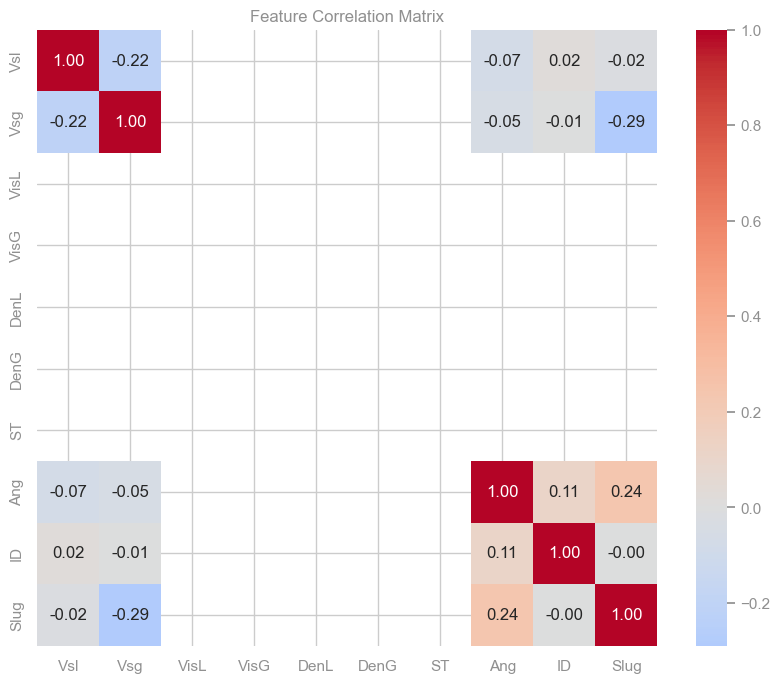

In [7]:
plt.figure(figsize=(10,8))

# Keep only numeric columns
numeric_data = dataset.drop(columns=["Flow Pattern"])

# Compute correlation matrix
corr = numeric_data.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


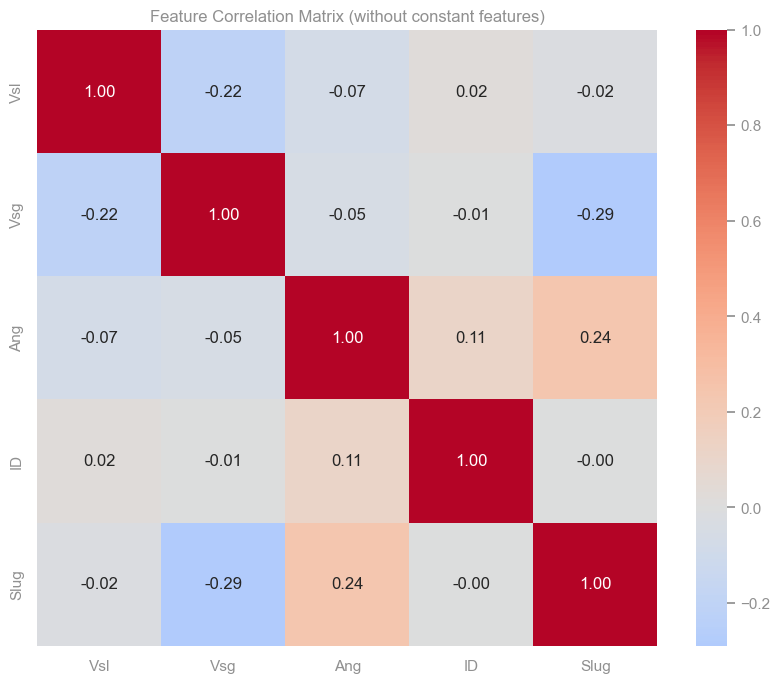

In [8]:
numeric_data = dataset.drop(columns=["Flow Pattern"])
# Drop constant features
numeric_data = numeric_data.loc[:, numeric_data.nunique() > 1]

corr = numeric_data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Matrix (without constant features)")
plt.show()


### Correlation Analysis

To better understand the relationships between input variables, we computed the **Pearson correlation matrix** across all numerical features.  

- No strong correlations were observed between the features.  
- This indicates that most variables contribute **independent information** about the flow patterns.  

Figure 4 below presents the correlation heatmap.


## 2.Building a Baseline Classifier

### 1. Prepare Features and Target

In [9]:
from sklearn.model_selection import train_test_split

# Features = all numeric columns except 'Flow Pattern' and 'Slug'
X = dataset.drop(columns=['Flow Pattern', 'Slug'])
y = dataset['Slug']   # target (0 = non-slug, 1 = slug)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4540
Test samples: 1135


### 2. Train a Baseline Model
We’ll start with `Extra Trees Classifier`, because tree ensembles work well on this kind of tabular dataset.

In [10]:
from sklearn.ensemble import ExtraTreesClassifier

# Initialize model
clf = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)

# Train
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)


### 3. Evaluate the Model

Classification Report:

              precision    recall  f1-score   support

    Non-slug       0.96      0.97      0.96       554
        Slug       0.97      0.96      0.97       581

    accuracy                           0.96      1135
   macro avg       0.96      0.96      0.96      1135
weighted avg       0.96      0.96      0.96      1135



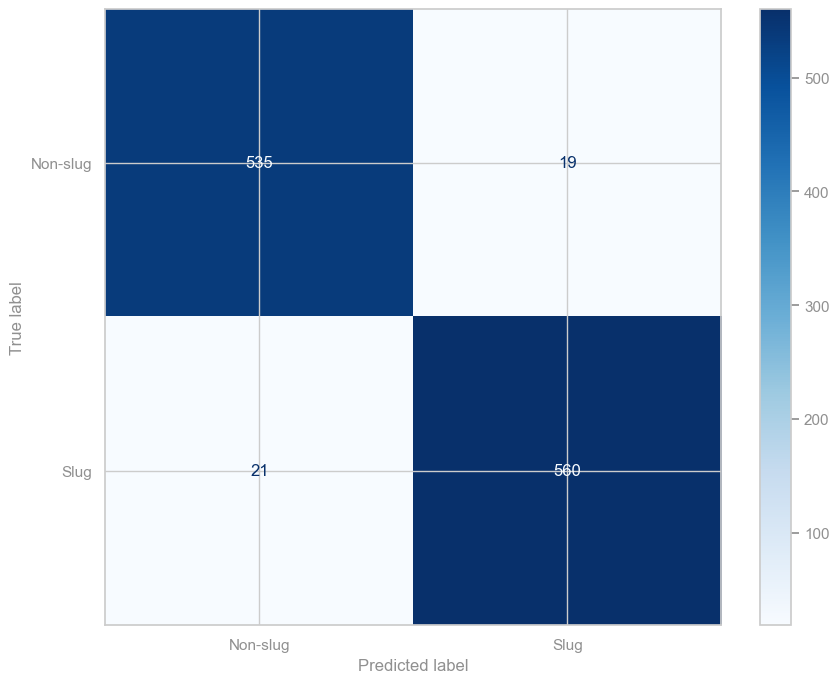

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-slug','Slug']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-slug','Slug'])
disp.plot(cmap="Blues")
plt.show()


### 4. Feature Importance

C:\Users\LUDMILA\AppData\Local\Temp\ipykernel_24980\3661177735.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


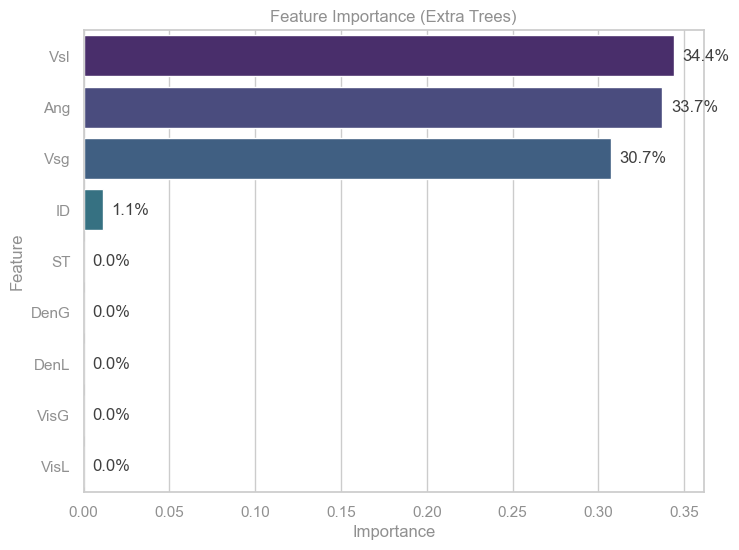

In [12]:
import numpy as np

# Get importances and sort
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = X.columns[indices]

# Convert to percentage
percentages = 100 * sorted_importances / sorted_importances.sum()

plt.figure(figsize=(8,6))
ax = sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")

# Add percentage labels on bars
for i, (imp, perc) in enumerate(zip(sorted_importances, percentages)):
    ax.text(imp + 0.005, i, f"{perc:.1f}%", va='center', color="#404040")

plt.title("Feature Importance (Extra Trees)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Feature Importance Analysis

We applied an **Extra Trees Classifier** to evaluate the relative importance of each feature in distinguishing slug from non-slug flows.  

## Key Findings
- **Most Influential Features**:  
  - Superficial liquid velocity (**Vsl**)  
  - Superficial gas velocity (**Vsg**)  
  - Pipe inclination angle (**Ang**)  
  - Pipe diameter (**ID**)  

- **Least Influential Features**:  
  - Surface tension (**ST**)  
  - Liquid density (**DenL**) and Gas density (**DenG**)  
  - Liquid viscosity (**VisL**) and Gas viscosity (**VisG**)  

These physical property features contributed **almost 0% importance**, which is explained by their **near-constant values** across the dataset. As such, they provide little to no discriminative information.  

---

## Decision
Based on these results, we retained the **dynamic and geometric variables** (**Vsl, Vsg, Ang, ID**) for the binary classification task.  
Removing low-variance features reduces dimensionality and ensures the models focus on variables that truly influence slug detection.  

Figure 5 presents the ranked feature importance plot.


---
---

## 3.Feature Selection

In [13]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)  # remove features with 0 variance
X_reduced = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
print("Kept features:", list(selected_features))


Kept features: ['Vsl', 'Vsg', 'Ang', 'ID']


**Feature Selection:**  
We retained the most informative variables — **Vsl, Vsg, Ang, ID** — while removing near-constant features (ST, DenL, DenG, VisL, VisG) that provided little discriminative power.


## 4.Retraining the Model :

We began by splitting the dataset into **training (80%)** and **testing (20%)** subsets to enable model training and unbiased performance evaluation.  


In [14]:
from sklearn.model_selection import train_test_split

# Train/test split (80/20)
X_reduced_train, X_reduced_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

print("Training samples:", X_reduced_train.shape[0])
print("Test samples:", X_reduced_test.shape[0])

Training samples: 4540
Test samples: 1135


# Comprehensive Grid Search for Multiple Classifiers

In this section, we will perform hyperparameter tuning for multiple classifiers and store the best parameters in a DataFrame for comparison and future use.


In [15]:
!pip install lightgbm
!pip install catboost


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("Libraries imported successfully!")


Libraries imported successfully!


In [17]:
X_reduced = dataset[["Vsl", "Vsg", "Ang", "ID"]]
y = dataset["Slug"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale features for algorithms that require it (SVM, Logistic Regression, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Features used: {list(X_reduced.columns)}")
print(f"Class distribution in training set:\n{y_train.value_counts().sort_index()}")


Training set size: 4540
Test set size: 1135
Features used: ['Vsl', 'Vsg', 'Ang', 'ID']
Class distribution in training set:
Slug
0    2216
1    2324
Name: count, dtype: int64


In [18]:
param_grids = {
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    
     'SVM': [
        {'kernel': ['linear'], 'C': [0.1, 1, 10]},
        {'kernel': ['rbf'], 'C': [1, 10], 'gamma': ['scale', 0.01]}
    ],
    
    'Logistic_Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    
    'MLP': {
        'hidden_layer_sizes': [(50,), (100,), (64, 32), (100, 50), (128, 64)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive'],
        'max_iter': [500, 1000]
    },
    
    'CatBoost': {
        'iterations': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8],
        'l2_leaf_reg': [1, 3, 5, 7, 9]
    },
    
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'num_leaves': [15, 31, 63],
        'subsample': [0.8, 0.9, 1.0]
    },
    
    'Extra_Trees': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    }
}

print("Parameter grids defined for all classifiers")


Parameter grids defined for all classifiers


In [19]:
# Define classifiers with their default parameters
classifiers = {
    'XGBoost': xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    ),
    
    'SVM': SVC(
        random_state=RANDOM_STATE,
        probability=True
    ),
    
    'Logistic_Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000
    ),
    
    'MLP': MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    
    'CatBoost': cb.CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=False
    ),
    
    'LightGBM': lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        verbosity=-1
    ),
    
    'Extra_Trees': ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Classifiers initialized")


Classifiers initialized


In [20]:
def perform_grid_search_and_store_results():
    """
    Perform grid search for all classifiers and store best parameters and metrics in a DataFrame
    """
    
    # Initialize results storage
    results_list = []
    best_models = {}
    
    # Cross-validation setup
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    print("Starting Grid Search for all classifiers...")
    print("="*60)
    
    for name, classifier in classifiers.items():
        print(f"\nTraining {name}...")
        
        try:
            # Choose appropriate data (scaled for SVM, LR, MLP)
            if name in ['SVM', 'Logistic_Regression', 'MLP']:
                X_train_data = X_train_scaled
                X_test_data = X_test_scaled
            else:
                X_train_data = X_train
                X_test_data = X_test
            
            # Perform grid search
            grid_search = GridSearchCV(
                estimator=classifier,
                param_grid=param_grids[name],
                cv=cv,
                scoring='accuracy',
                n_jobs=-1,
                verbose=0
            )
            
            # Fit the grid search
            grid_search.fit(X_train_data, y_train)
            
            # Get best model and predictions
            best_model = grid_search.best_estimator_
            y_pred = best_model.predict(X_test_data)
            y_pred_proba = best_model.predict_proba(X_test_data)[:, 1] if hasattr(best_model, 'predict_proba') else None
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            # Cross-validation score
            cv_scores = cross_val_score(best_model, X_train_data, y_train, cv=cv, scoring='accuracy')
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # Store results
            result = {
                'Classifier': name,
                'Best_Params': grid_search.best_params_,
                'Best_CV_Score': grid_search.best_score_,
                'CV_Score_Mean': cv_mean,
                'CV_Score_Std': cv_std,
                'Test_Accuracy': accuracy,
                'Test_F1_Score': f1,
                'Test_ROC_AUC': roc_auc,
                'Fit_Time': grid_search.cv_results_['mean_fit_time'][grid_search.best_index_],
                'Predict_Time': grid_search.cv_results_['mean_score_time'][grid_search.best_index_]
            }
            
            results_list.append(result)
            best_models[name] = best_model
            
            print(f"✓ {name} completed")
            print(f"  Best CV Score: {grid_search.best_score_:.4f}")
            print(f"  Test Accuracy: {accuracy:.4f}")
            print(f"  Best Parameters: {grid_search.best_params_}")
            
        except Exception as e:
            print(f"✗ Error with {name}: {str(e)}")
            continue
    
    # Create results DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Sort by test accuracy
    results_df = results_df.sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)
    
    return results_df, best_models

results_df, best_models = perform_grid_search_and_store_results()


Starting Grid Search for all classifiers...

Training XGBoost...
✓ XGBoost completed
  Best CV Score: 0.9601
  Test Accuracy: 0.9709
  Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.9}

Training SVM...
✓ SVM completed
  Best CV Score: 0.8275
  Test Accuracy: 0.8264
  Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Training Logistic_Regression...
✓ Logistic_Regression completed
  Best CV Score: 0.6800
  Test Accuracy: 0.6749
  Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}

Training MLP...
✓ MLP completed
  Best CV Score: 0.9388
  Test Accuracy: 0.9621
  Best Parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'constant', 'max_iter': 500}

Training CatBoost...
✓ CatBoost completed
  Best CV Score: 0.9641
  Test Accuracy: 0.9718
  Best Parameters: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

Train

Exception in thread Thread-43 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\LUDMILA\anaconda3\envs\DM_ENV\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\LUDMILA\anaconda3\envs\DM_ENV\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\LUDMILA\anaconda3\envs\DM_ENV\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 103: invalid start byte


✓ LightGBM completed
  Best CV Score: 0.9610
  Test Accuracy: 0.9753
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 63, 'subsample': 0.8}

Training Extra_Trees...
✓ Extra_Trees completed
  Best CV Score: 0.9663
  Test Accuracy: 0.9718
  Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [21]:

print("\n" + "="*80)
print("GRID SEARCH RESULTS SUMMARY")
print("="*80)

# Display the results DataFrame
print("\nResults DataFrame:")
print(results_df[['Classifier', 'Test_Accuracy', 'Test_F1_Score', 'Test_ROC_AUC', 'CV_Score_Mean', 'CV_Score_Std']].round(4))

print(f"\nTotal models trained: {len(results_df)}")
print(f"Best performing classifier: {results_df.iloc[0]['Classifier']}")
print(f"Best test accuracy: {results_df.iloc[0]['Test_Accuracy']:.4f}")



GRID SEARCH RESULTS SUMMARY

Results DataFrame:
            Classifier  Test_Accuracy  Test_F1_Score  Test_ROC_AUC  \
0             LightGBM         0.9753         0.9759        0.9950   
1             CatBoost         0.9718         0.9725        0.9955   
2          Extra_Trees         0.9718         0.9723        0.9958   
3              XGBoost         0.9709         0.9716        0.9961   
4                  MLP         0.9621         0.9631        0.9910   
5                  SVM         0.8264         0.8387        0.9252   
6  Logistic_Regression         0.6749         0.7060        0.7400   

   CV_Score_Mean  CV_Score_Std  
0         0.9610        0.0066  
1         0.9641        0.0062  
2         0.9663        0.0066  
3         0.9604        0.0050  
4         0.9388        0.0059  
5         0.8275        0.0085  
6         0.6800        0.0094  

Total models trained: 7
Best performing classifier: LightGBM
Best test accuracy: 0.9753


## Models Evaluation:
---

In [22]:
# Display best parameters for each classifier
print("\n" + "="*80)
print("BEST PARAMETERS FOR EACH CLASSIFIER")
print("="*80)

for idx, row in results_df.iterrows():
    print(f"\n{row['Classifier']}:")
    print(f"  Test Accuracy: {row['Test_Accuracy']:.4f}")
    print(f"  Best Parameters:")
    for param, value in row['Best_Params'].items():
        print(f"    {param}: {value}")
    print("-" * 40)



BEST PARAMETERS FOR EACH CLASSIFIER

LightGBM:
  Test Accuracy: 0.9753
  Best Parameters:
    learning_rate: 0.1
    max_depth: 7
    n_estimators: 200
    num_leaves: 63
    subsample: 0.8
----------------------------------------

CatBoost:
  Test Accuracy: 0.9718
  Best Parameters:
    depth: 8
    iterations: 300
    l2_leaf_reg: 1
    learning_rate: 0.1
----------------------------------------

Extra_Trees:
  Test Accuracy: 0.9718
  Best Parameters:
    max_depth: 20
    max_features: None
    min_samples_leaf: 1
    min_samples_split: 2
    n_estimators: 500
----------------------------------------

XGBoost:
  Test Accuracy: 0.9709
  Best Parameters:
    colsample_bytree: 1.0
    learning_rate: 0.1
    max_depth: 7
    n_estimators: 200
    subsample: 0.9
----------------------------------------

MLP:
  Test Accuracy: 0.9621
  Best Parameters:
    activation: tanh
    alpha: 0.001
    hidden_layer_sizes: (128, 64)
    learning_rate: constant
    max_iter: 500
--------------------

In [23]:
# Create a detailed comparison DataFrame
detailed_results = results_df.copy()

# Add ranking
detailed_results['Rank'] = range(1, len(detailed_results) + 1)

# Create a more readable version of best parameters
def format_params(params_dict):
    return ', '.join([f"{k}={v}" for k, v in params_dict.items()])

detailed_results['Best_Params_Formatted'] = detailed_results['Best_Params'].apply(format_params)

# Display the detailed results
print("\n" + "="*100)
print("DETAILED RESULTS COMPARISON")
print("="*100)

display_columns = ['Rank', 'Classifier', 'Test_Accuracy', 'Test_F1_Score', 'Test_ROC_AUC', 
                  'CV_Score_Mean', 'CV_Score_Std', 'Best_Params_Formatted']

print(detailed_results[display_columns].to_string(index=False))

# Save results to CSV
results_df.to_csv('grid_search_results.csv', index=False)
print(f"\nResults saved to 'grid_search_results.csv'")



DETAILED RESULTS COMPARISON
 Rank          Classifier  Test_Accuracy  Test_F1_Score  Test_ROC_AUC  CV_Score_Mean  CV_Score_Std                                                                            Best_Params_Formatted
    1            LightGBM       0.975330       0.975945      0.994978       0.961013      0.006630                   learning_rate=0.1, max_depth=7, n_estimators=200, num_leaves=63, subsample=0.8
    2            CatBoost       0.971806       0.972509      0.995534       0.964097      0.006214                                        depth=8, iterations=300, l2_leaf_reg=1, learning_rate=0.1
    3         Extra_Trees       0.971806       0.972318      0.995835       0.966300      0.006556       max_depth=20, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=500
    4             XGBoost       0.970925       0.971625      0.996103       0.960352      0.005023            colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=200, subsa

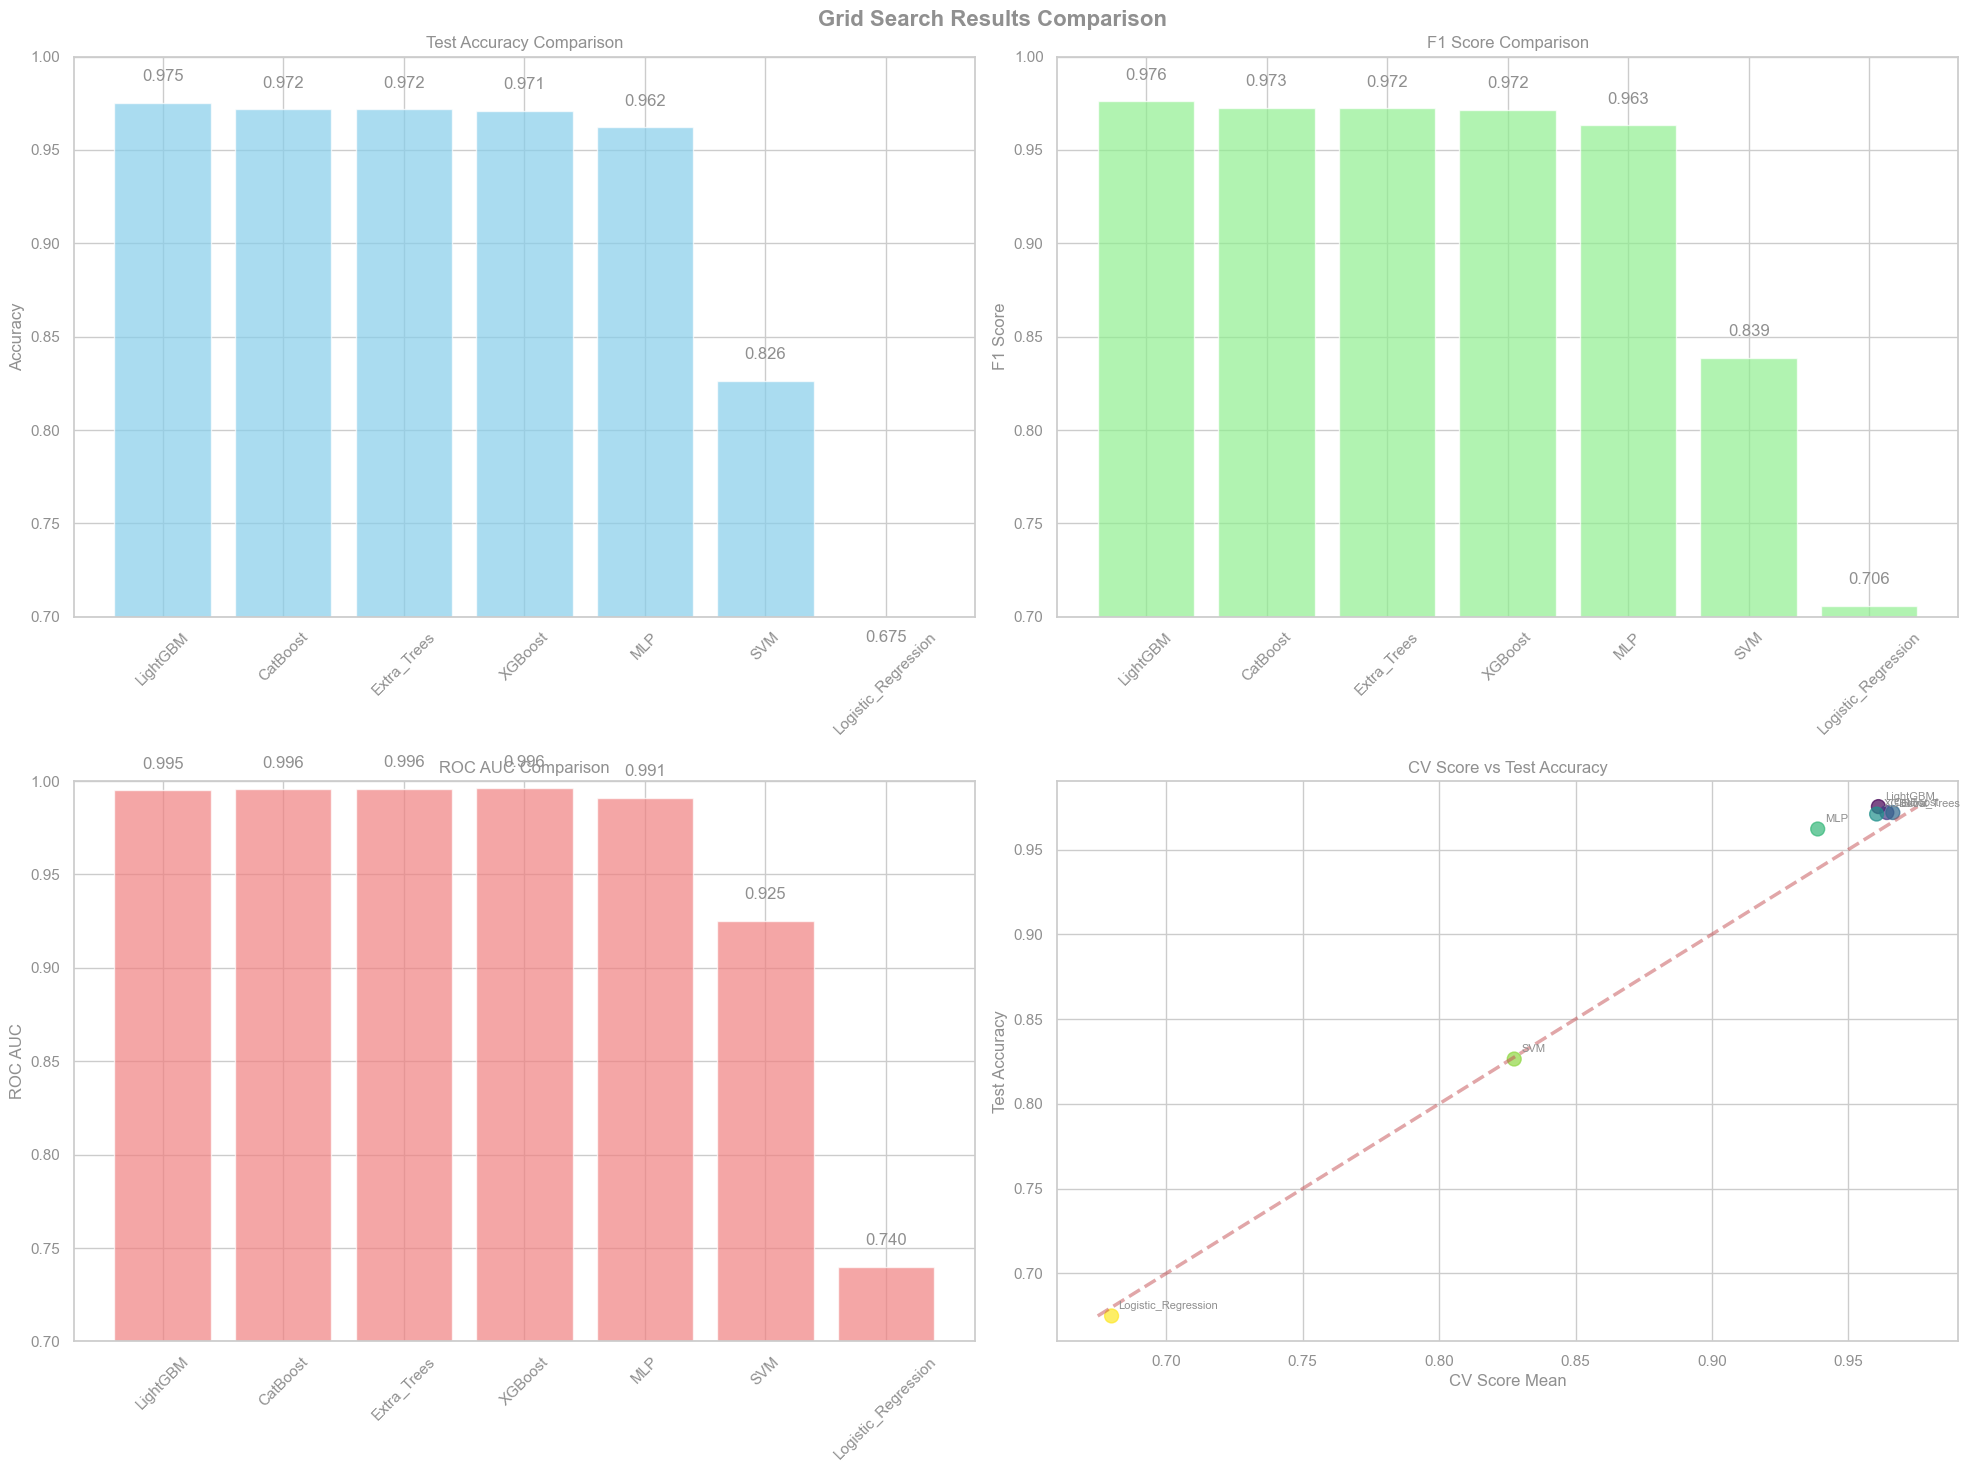

In [24]:
# Visualize results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Grid Search Results Comparison', fontsize=16, fontweight='bold')

# 1. Accuracy comparison
axes[0, 0].bar(results_df['Classifier'], results_df['Test_Accuracy'], color='skyblue', alpha=0.7)
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim(0.7, 1.0)

# Add value labels on bars
for i, v in enumerate(results_df['Test_Accuracy']):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. F1 Score comparison
axes[0, 1].bar(results_df['Classifier'], results_df['Test_F1_Score'], color='lightgreen', alpha=0.7)
axes[0, 1].set_title('F1 Score Comparison')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim(0.7, 1.0)

for i, v in enumerate(results_df['Test_F1_Score']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 3. ROC AUC comparison
axes[1, 0].bar(results_df['Classifier'], results_df['Test_ROC_AUC'], color='lightcoral', alpha=0.7)
axes[1, 0].set_title('ROC AUC Comparison')
axes[1, 0].set_ylabel('ROC AUC')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0.7, 1.0)

for i, v in enumerate(results_df['Test_ROC_AUC']):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 4. CV Score vs Test Accuracy
axes[1, 1].scatter(results_df['CV_Score_Mean'], results_df['Test_Accuracy'], 
                   s=100, alpha=0.7, c=range(len(results_df)), cmap='viridis')
for i, txt in enumerate(results_df['Classifier']):
    axes[1, 1].annotate(txt, (results_df['CV_Score_Mean'].iloc[i], results_df['Test_Accuracy'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1, 1].set_xlabel('CV Score Mean')
axes[1, 1].set_ylabel('Test Accuracy')
axes[1, 1].set_title('CV Score vs Test Accuracy')

# Add diagonal line for perfect correlation
min_val = min(results_df['CV_Score_Mean'].min(), results_df['Test_Accuracy'].min())
max_val = max(results_df['CV_Score_Mean'].max(), results_df['Test_Accuracy'].max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)

plt.tight_layout()
plt.savefig('images/grid_search_comparison.pdf', bbox_inches='tight')
plt.show()


In [25]:
# Save best models for future use
import joblib
import os

# Create models directory
models_dir = 'best_models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Save each best model
for name, model in best_models.items():
    model_filename = f"{models_dir}/best_{name.lower().replace('_', '_')}_model.pkl"
    joblib.dump(model, model_filename)
    print(f"Saved {name} model to {model_filename}")

# Save scaler for models that need it
scaler_filename = f"{models_dir}/scaler.pkl"
joblib.dump(scaler, scaler_filename)
print(f"Saved scaler to {scaler_filename}")

# Save feature names
feature_names = list(X_reduced.columns)
feature_filename = f"{models_dir}/feature_names.pkl"
joblib.dump(feature_names, feature_filename)
print(f"Saved feature names to {feature_filename}")

print(f"\nAll models and utilities saved in '{models_dir}' directory")


Saved XGBoost model to best_models/best_xgboost_model.pkl
Saved SVM model to best_models/best_svm_model.pkl
Saved Logistic_Regression model to best_models/best_logistic_regression_model.pkl
Saved MLP model to best_models/best_mlp_model.pkl
Saved CatBoost model to best_models/best_catboost_model.pkl
Saved LightGBM model to best_models/best_lightgbm_model.pkl
Saved Extra_Trees model to best_models/best_extra_trees_model.pkl
Saved scaler to best_models/scaler.pkl
Saved feature names to best_models/feature_names.pkl

All models and utilities saved in 'best_models' directory


In [26]:
# Function to load and use saved models for predictions
def load_model_and_predict(model_name, new_data):
    """
    Load a saved model and make predictions on new data
    
    Parameters:
    - model_name: Name of the classifier (e.g., 'XGBoost', 'SVM', etc.)
    - new_data: New data for prediction (must have same features as training data)
    
    Returns:
    - predictions: Model predictions
    - probabilities: Prediction probabilities (if available)
    """
    
    # Load model
    model_filename = f"{models_dir}/best_{model_name.lower().replace('_', '_')}_model.pkl"
    model = joblib.load(model_filename)
    
    # Check if data needs scaling
    if model_name in ['SVM', 'Logistic_Regression', 'MLP']:
        scaler = joblib.load(f"{models_dir}/scaler.pkl")
        new_data_scaled = scaler.transform(new_data)
        predictions = model.predict(new_data_scaled)
        probabilities = model.predict_proba(new_data_scaled) if hasattr(model, 'predict_proba') else None
    else:
        predictions = model.predict(new_data)
        probabilities = model.predict_proba(new_data) if hasattr(model, 'predict_proba') else None
    
    return predictions, probabilities

# Example usage (uncomment to test):
# predictions, probabilities = load_model_and_predict('XGBoost', X_test.iloc[:5])
# print(f"Predictions: {predictions}")
# print(f"Probabilities: {probabilities}")

print("Model loading function created successfully!")


Model loading function created successfully!


## Summary

This comprehensive grid search implementation provides:

### **What was accomplished:**
1. **Hyperparameter tuning** for 7 different classifiers:
   - XGBoost
   - Support Vector Machine (SVM)
   - Logistic Regression
   - Multi-Layer Perceptron (MLP)
   - CatBoost
   - LightGBM
   - Extra Trees Classifier

2. **Comprehensive evaluation** with:
   - 5-fold cross-validation
   - Multiple metrics (Accuracy, F1-Score, ROC-AUC)
   - Training and prediction time measurement

3. **Results storage** in:
   - `grid_search_results.csv` - Complete results DataFrame
   - `best_models/` directory - Saved trained models
   - `images/grid_search_comparison.pdf` - Visualization plots

4. **Model persistence** with:
   - Best parameters for each classifier
   - Saved models for future predictions
   - Helper function for loading and using saved models

### **Key Features:**
- **Automatic feature scaling** for algorithms that require it (SVM, Logistic Regression, MLP)
- **Error handling** to ensure robust execution
- **Reproducible results** with fixed random seeds
- **Parallel processing** for faster grid search execution
- **Comprehensive visualization** of results

### **Usage:**
- Results are automatically sorted by test accuracy
- All best parameters are stored in the results DataFrame
- Models can be loaded and used for new predictions
- Results are saved for future reference and analysis



---
---

In [27]:
# Import additional libraries for learning curves and detailed analysis
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("Libraries imported successfully for detailed model analysis!")


Libraries imported successfully for detailed model analysis!


In [28]:
# Function to plot confusion matrices for all models
def plot_confusion_matrices(best_models, X_test_data, y_test, model_names):
    """
    Create confusion matrix plots for all trained models
    """
    n_models = len(best_models)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    for i, (model_name, model) in enumerate(best_models.items()):
        # Get predictions
        if model_name in ['SVM', 'Logistic_Regression', 'MLP']:
            predictions = model.predict(X_test_scaled)
        else:
            predictions = model.predict(X_test_data)
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, predictions)
        
        # Plot confusion matrix
        ax = axes_flat[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Non-slug', 'Slug'],
                   yticklabels=['Non-slug', 'Slug'])
        
        ax.set_title(f'{model_name}\nConfusion Matrix')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        
        # Calculate and display accuracy
        accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
        ax.text(0.5, -0.15, f'Accuracy: {accuracy:.3f}', 
                transform=ax.transAxes, ha='center', fontweight='bold')
    
    # Hide empty subplots
    for i in range(len(best_models), len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('images/confusion_matrices_all_models.pdf', bbox_inches='tight', dpi=300)
    plt.show()

print("Confusion matrix plotting function created!")


Confusion matrix plotting function created!


In [29]:
# Function to plot learning curves for all models
def plot_learning_curves(best_models, X_train_data, y_train, X_test_data, y_test):
    """
    Create learning curve plots for all trained models
    """
    n_models = len(best_models)
    n_cols = 2
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    # Define training sizes for learning curve
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    for i, (model_name, model) in enumerate(best_models.items()):
        # Choose appropriate data (scaled for SVM, LR, MLP)
        if model_name in ['SVM', 'Logistic_Regression', 'MLP']:
            X_train_curve = X_train_scaled
            X_test_curve = X_test_scaled
        else:
            X_train_curve = X_train_data
            X_test_curve = X_test_data
        
        try:
            # Calculate learning curve
            train_sizes_abs, train_scores, val_scores = learning_curve(
                model, X_train_curve, y_train,
                train_sizes=train_sizes,
                cv=5,  # 5-fold cross-validation
                scoring='accuracy',
                n_jobs=-1,
                random_state=42
            )
            
            # Calculate mean and std
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            # Plot learning curve
            ax = axes_flat[i]
            
            # Plot training and validation scores
            ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Score')
            ax.fill_between(train_sizes_abs, train_mean - train_std, 
                           train_mean + train_std, alpha=0.1, color='blue')
            
            ax.plot(train_sizes_abs, val_mean, 'o-', color='red', label='Validation Score')
            ax.fill_between(train_sizes_abs, val_mean - val_std, 
                           val_mean + val_std, alpha=0.1, color='red')
            
            ax.set_title(f'{model_name} Learning Curve')
            ax.set_xlabel('Training Set Size')
            ax.set_ylabel('Accuracy Score')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # Add final accuracy annotation
            final_acc = val_mean[-1]
            ax.annotate(f'Final CV Score: {final_acc:.3f}', 
                       xy=(train_sizes_abs[-1], final_acc),
                       xytext=(10, 10), textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                       arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
            
        except Exception as e:
            # If learning curve fails, show error message
            ax = axes_flat[i]
            ax.text(0.5, 0.5, f'Error generating\nlearning curve\nfor {model_name}', 
                   ha='center', va='center', transform=ax.transAxes,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.3))
            ax.set_title(f'{model_name} Learning Curve (Error)')
            print(f"Error with {model_name}: {str(e)}")
    
    # Hide empty subplots
    for i in range(len(best_models), len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('images/learning_curves_all_models.pdf', bbox_inches='tight', dpi=300)
    plt.show()

print("Learning curve plotting function created!")


Learning curve plotting function created!


## Generate Confusion Matrices for All Models

Let's create confusion matrix plots for each of our trained models to understand their classification performance in detail.


Generating confusion matrices for all trained models...


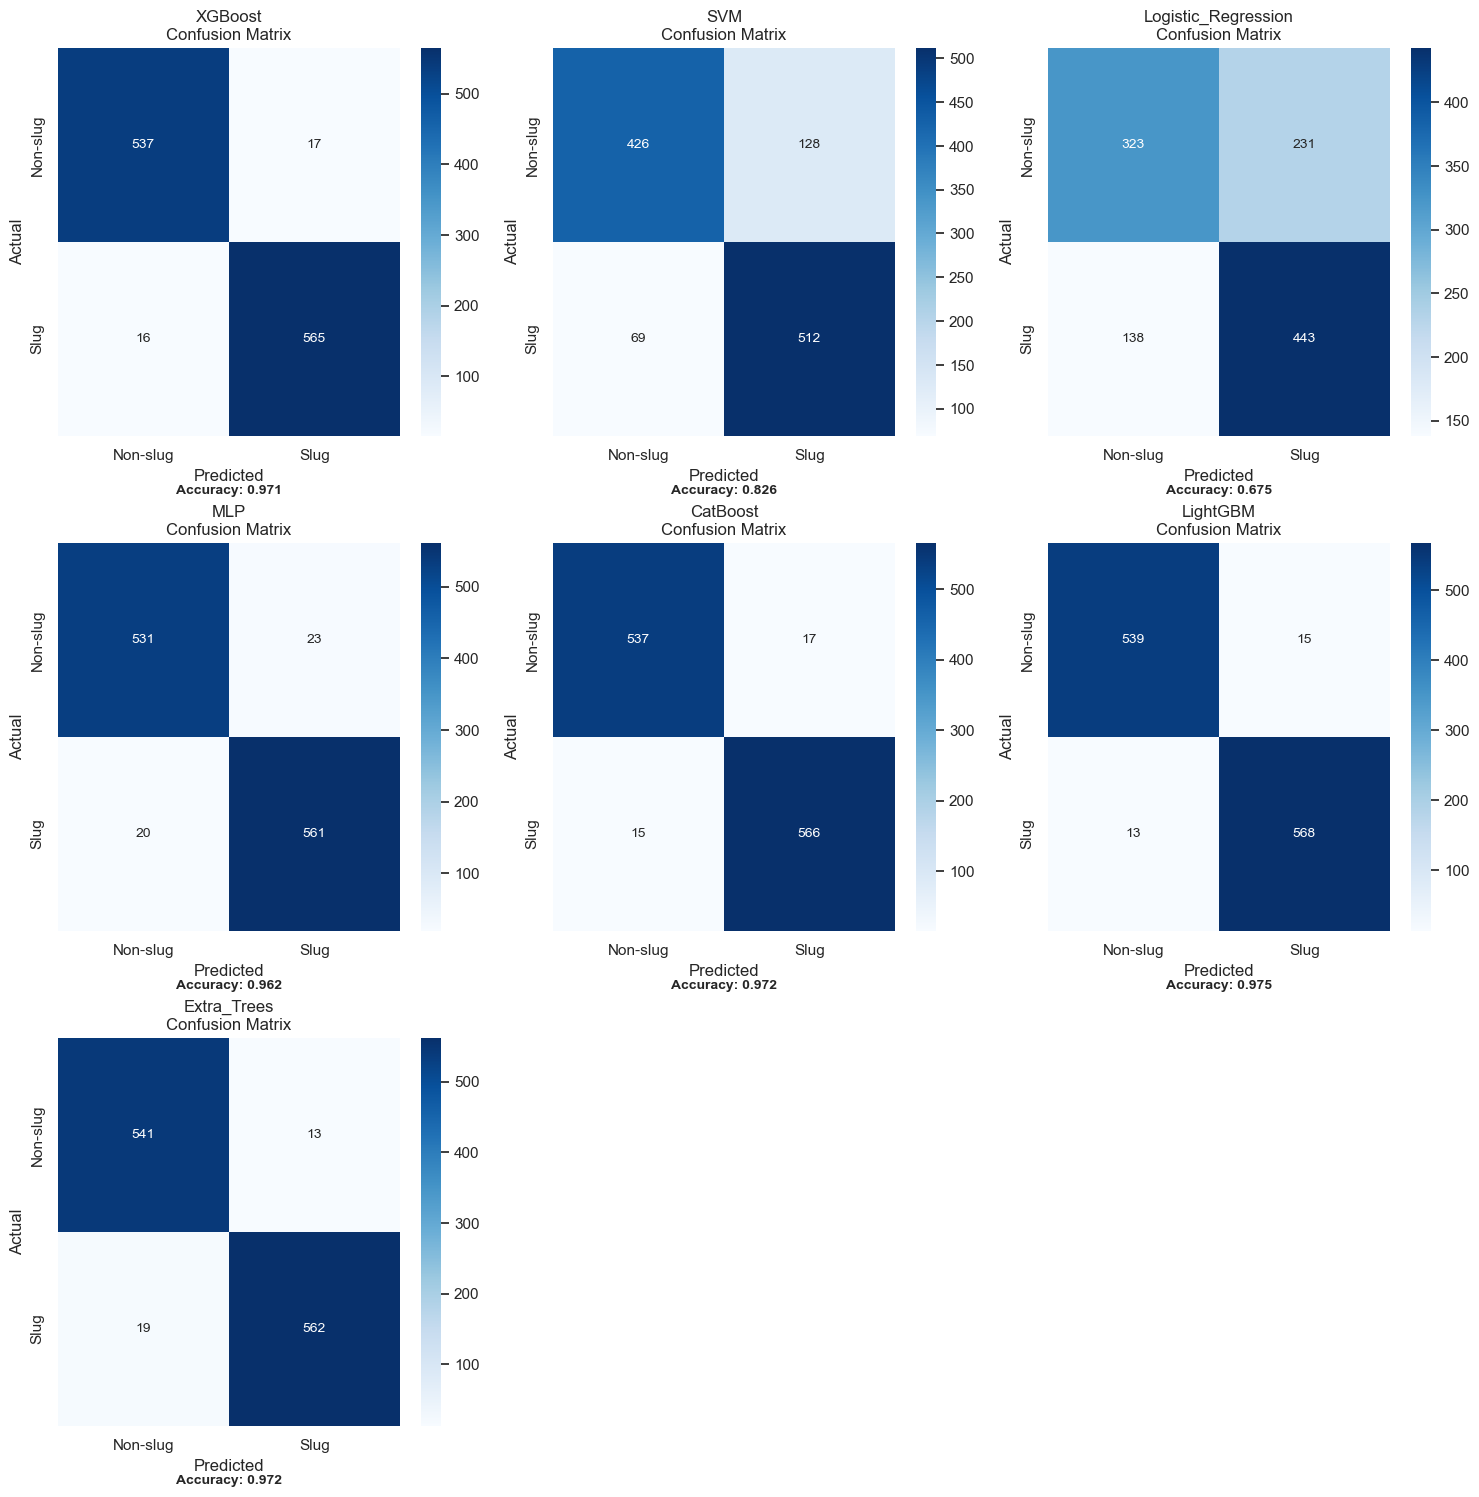


Confusion matrices generated and saved to 'images/confusion_matrices_all_models.pdf'


In [30]:
# Generate confusion matrices for all models
print("Generating confusion matrices for all trained models...")
print("="*60)

# Plot confusion matrices
plot_confusion_matrices(best_models, X_test, y_test, list(best_models.keys()))

print("\nConfusion matrices generated and saved to 'images/confusion_matrices_all_models.pdf'")


## Generate Learning Curves for All Models

Now let's create learning curve plots to analyze how each model's performance changes with increasing training data size. This helps us understand:
- **Overfitting**: Large gap between training and validation scores
- **Underfitting**: Both scores are low and close together
- **Optimal data size**: Where validation score plateaus


Generating learning curves for all trained models...
Note: This may take several minutes as it involves training models on different data sizes...


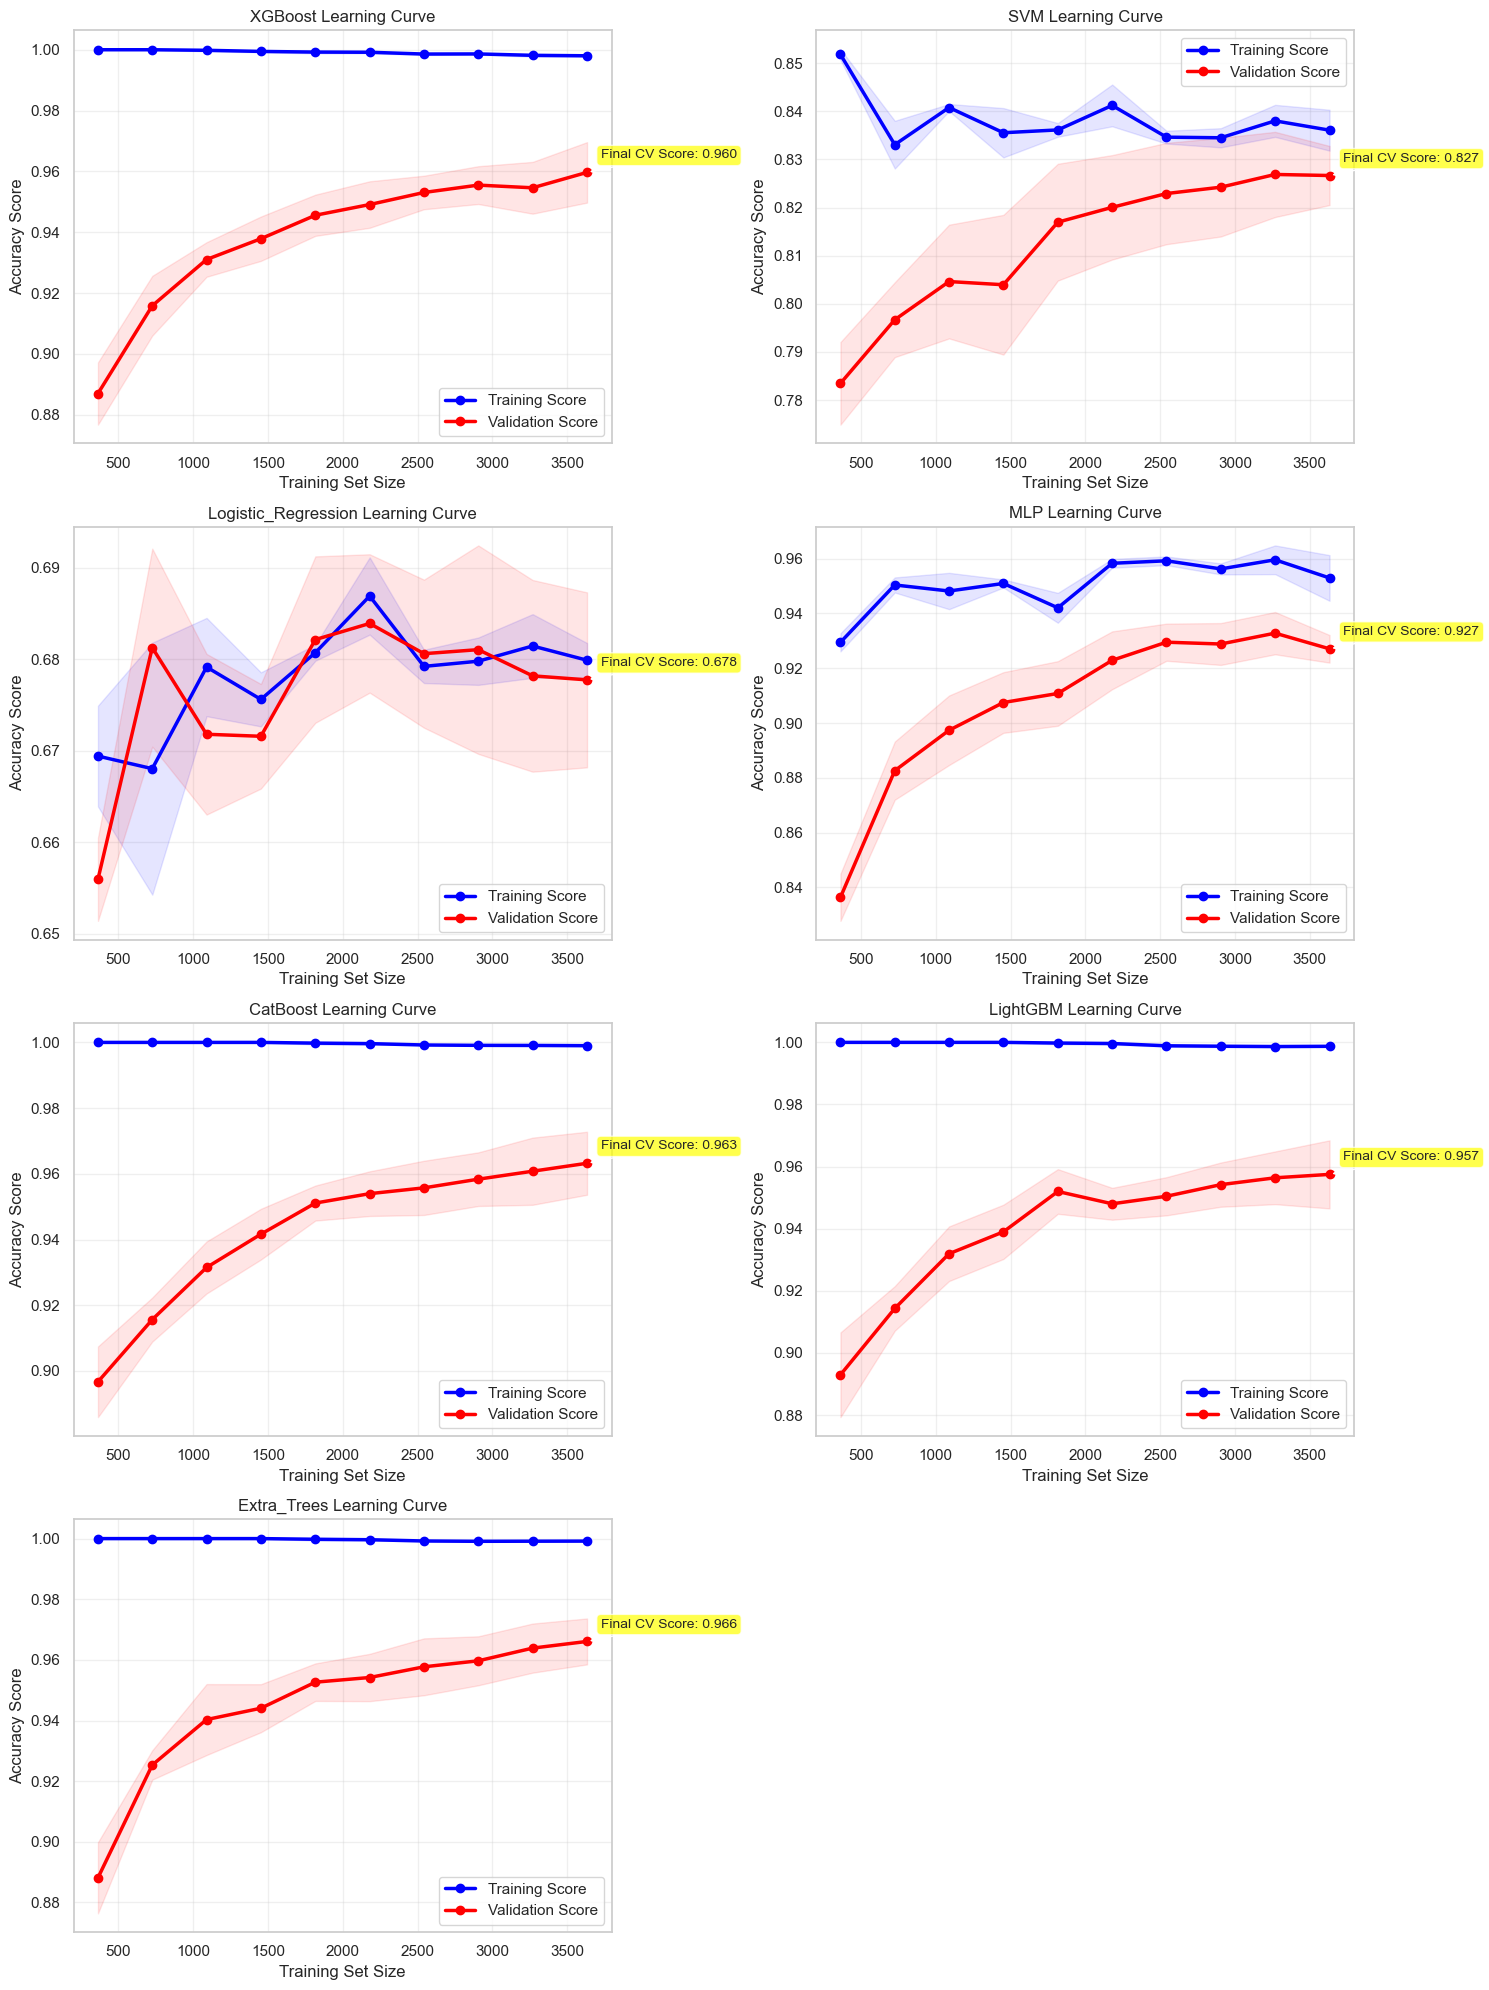


Learning curves generated and saved to 'images/learning_curves_all_models.pdf'


In [31]:
# Generate learning curves for all models
print("Generating learning curves for all trained models...")
print("="*60)
print("Note: This may take several minutes as it involves training models on different data sizes...")

# Plot learning curves
plot_learning_curves(best_models, X_train, y_train, X_test, y_test)

print("\nLearning curves generated and saved to 'images/learning_curves_all_models.pdf'")


### Observations from Learning Curves

### 1. XGBoost
- **Final CV Score: 0.960**
- Training and validation curves are high and close together.
- Shows strong generalization and stability with increasing training size.
- **Observation:** Excellent balance between bias and variance.

---

### 2. SVM
- **Final CV Score: 0.827**
- Training and validation scores remain low compared to other models.
- Both curves are close → indicates underfitting rather than overfitting.
- **Observation:** Model too simple with linear kernel; may need nonlinear kernels (RBF) or feature engineering.

---

### 3. Logistic Regression
- **Final CV Score: 0.678**
- Both training and validation curves plateau at a low level.
- Very close curves indicate severe underfitting.
- **Observation:** Linear model cannot capture dataset complexity.

---

### 4. MLP (Neural Network)
- **Final CV Score: 0.927**
- Training accuracy rises steeply, validation follows closely with a slight gap.
- Indicates a good fit, with mild variance.
- **Observation:** Strong results, but still slightly behind tree-based methods.

---

### 5. CatBoost
- **Final CV Score: 0.963**
- High training and validation accuracy, both curves nearly overlap.
- Excellent stability and generalization.
- **Observation:** One of the best-performing models, robust and consistent.

---

### 6. LightGBM
- **Final CV Score: 0.957**
- Curves almost identical to CatBoost/XGBoost.
- High, stable validation accuracy with minimal overfitting.
- **Observation:** Another strong tree-based method, highly competitive.

---

### 7. Extra Trees
- **Final CV Score: 0.966** (highest among all models)
- Training and validation scores are both extremely high and closely aligned.
- Very stable with almost no overfitting.
- **Observation:** Best performer overall on this dataset.

---

### Conclusions

- **Tree-based models (Extra Trees, CatBoost, LightGBM, XGBoost)** dominate performance with CV scores above **0.95**.  
- **Extra Trees** achieved the best overall result (**0.966**) and shows exceptional generalization.  
- **MLP** performs reasonably well (**0.927**) but does not match the ensemble tree models.  
- **SVM (0.827)** and **Logistic Regression (0.678)** underperform, indicating that linear/low-complexity models cannot capture the dataset’s structure.  

**Final Conclusion:**  
➡️ For this dataset, **ensemble tree-based methods** (especially Extra Trees, CatBoost, LightGBM) are the most effective and reliable.  
➡️ Simpler models like SVM (linear) and Logistic Regression underfit the data and are not suitable choices.  


In [32]:
# Create a detailed performance summary table
def create_performance_summary(results_df, best_models, X_test, y_test):
    """
    Create a comprehensive performance summary table with confusion matrix metrics
    """
    summary_data = []
    
    for idx, row in results_df.iterrows():
        model_name = row['Classifier']
        model = best_models[model_name]
        
        # Get predictions
        if model_name in ['SVM', 'Logistic_Regression', 'MLP']:
            predictions = model.predict(X_test_scaled)
        else:
            predictions = model.predict(X_test)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_test, predictions)
        
        # Calculate metrics
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        summary_data.append({
            'Model': model_name,
            'Test_Accuracy': row['Test_Accuracy'],
            'F1_Score': row['Test_F1_Score'],
            'ROC_AUC': row['Test_ROC_AUC'],
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'True_Positives': tp,
            'False_Positives': fp,
            'True_Negatives': tn,
            'False_Negatives': fn
        })
    
    return pd.DataFrame(summary_data)

# Create and display performance summary
performance_summary = create_performance_summary(results_df, best_models, X_test, y_test)

print("="*80)
print("COMPREHENSIVE MODEL PERFORMANCE SUMMARY")
print("="*80)
print(performance_summary.round(4))

# Save summary to CSV
performance_summary.to_csv('model_performance_summary.csv', index=False)
print(f"\nPerformance summary saved to 'model_performance_summary.csv'")


COMPREHENSIVE MODEL PERFORMANCE SUMMARY
                 Model  Test_Accuracy  F1_Score  ROC_AUC  Precision  Recall  \
0             LightGBM         0.9753    0.9759   0.9950     0.9743  0.9776   
1             CatBoost         0.9718    0.9725   0.9955     0.9708  0.9742   
2          Extra_Trees         0.9718    0.9723   0.9958     0.9774  0.9673   
3              XGBoost         0.9709    0.9716   0.9961     0.9708  0.9725   
4                  MLP         0.9621    0.9631   0.9910     0.9606  0.9656   
5                  SVM         0.8264    0.8387   0.9252     0.8000  0.8812   
6  Logistic_Regression         0.6749    0.7060   0.7400     0.6573  0.7625   

   Specificity  True_Positives  False_Positives  True_Negatives  \
0       0.9729             568               15             539   
1       0.9693             566               17             537   
2       0.9765             562               13             541   
3       0.9693             565               17            

----
---
----
-----

# Ensemble Models: Majority Voting and Advanced Ensemble

In this section, we will create and evaluate ensemble models to potentially improve upon individual model performance:

1. **Majority Voting Ensemble**: Combines predictions from multiple models using simple voting
2. **Advanced Ensemble**: Uses LightGBM, CatBoost, Extra Trees, XGBoost, and MLP with their best parameters

The goal is to leverage the strengths of multiple models to achieve better overall performance than any single model.


In [33]:
# Import ensemble libraries
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("Ensemble libraries imported successfully!")


Ensemble libraries imported successfully!


In [34]:
# Create individual models with their best parameters from grid search
def create_best_models():
    """
    Create individual models with their best parameters from the grid search results
    """
    models = {}
    
    # Get best parameters for each model from results_df
    for idx, row in results_df.iterrows():
        model_name = row['Classifier']
        best_params = row['Best_Params']
        
        if model_name == 'XGBoost':
            models[model_name] = xgb.XGBClassifier(
                **best_params,
                random_state=RANDOM_STATE,
                eval_metric='logloss',
                verbosity=0
            )
        elif model_name == 'LightGBM':
            models[model_name] = lgb.LGBMClassifier(
                **best_params,
                random_state=RANDOM_STATE,
                verbosity=-1
            )
        elif model_name == 'CatBoost':
            models[model_name] = cb.CatBoostClassifier(
                **best_params,
                random_state=RANDOM_STATE,
                verbose=False
            )
        elif model_name == 'Extra_Trees':
            models[model_name] = ExtraTreesClassifier(
                **best_params,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        elif model_name == 'MLP':
            models[model_name] = MLPClassifier(
                **best_params,
                random_state=RANDOM_STATE
            )
    
    return models

# Create the best individual models
best_individual_models = create_best_models()
print("Best individual models created with optimal parameters:")
for name, model in best_individual_models.items():
    print(f"✓ {name}")


Best individual models created with optimal parameters:
✓ LightGBM
✓ CatBoost
✓ Extra_Trees
✓ XGBoost
✓ MLP


In [35]:
# Create Majority Voting Ensemble
print("Creating Majority Voting Ensemble...")

# Create voting classifier with the best models
voting_classifier = VotingClassifier(
    estimators=list(best_individual_models.items()),
    voting='hard'  # Use hard voting (majority vote)
)

print(f"Majority Voting Ensemble created with {len(best_individual_models)} models:")
for name in best_individual_models.keys():
    print(f"  - {name}")

# Create Advanced Stacking Ensemble
print("\nCreating Advanced Stacking Ensemble...")

# Create stacking classifier with logistic regression as meta-learner
stacking_classifier = StackingClassifier(
    estimators=list(best_individual_models.items()),
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    cv=5,  # 5-fold cross-validation for meta-learner training
    stack_method='predict_proba'  # Use probability predictions for stacking
)

print(f"Stacking Ensemble created with Logistic Regression meta-learner")
print("✓ Both ensemble models ready for training")


Creating Majority Voting Ensemble...
Majority Voting Ensemble created with 5 models:
  - LightGBM
  - CatBoost
  - Extra_Trees
  - XGBoost
  - MLP

Creating Advanced Stacking Ensemble...
Stacking Ensemble created with Logistic Regression meta-learner
✓ Both ensemble models ready for training


In [ ]:
# Train and Evaluate Ensemble Models
print("Training and evaluating ensemble models...")
print("="*60)

# Store ensemble models and their results
ensemble_models = {}
ensemble_results = {}

# 1. Train and evaluate Majority Voting Ensemble
print("\n1. Training Majority Voting Ensemble...")
voting_classifier.fit(X_train, y_train)
y_pred_voting = voting_classifier.predict(X_test)
voting_accuracy = accuracy_score(y_test, y_pred_voting)

ensemble_models['Majority_Voting'] = voting_classifier
ensemble_results['Majority_Voting'] = {
    'accuracy': voting_accuracy,
    'predictions': y_pred_voting,
    'model': voting_classifier
}

print(f"   ✓ Majority Voting Accuracy: {voting_accuracy:.4f}")

# 2. Train and evaluate Stacking Ensemble
print("\n2. Training Stacking Ensemble...")
stacking_classifier.fit(X_train, y_train)
y_pred_stacking = stacking_classifier.predict(X_test)
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)

ensemble_models['Stacking_Ensemble'] = stacking_classifier
ensemble_results['Stacking_Ensemble'] = {
    'accuracy': stacking_accuracy,
    'predictions': y_pred_stacking,
    'model': stacking_classifier
}

print(f"   ✓ Stacking Ensemble Accuracy: {stacking_accuracy:.4f}")

# 3. Calculate cross-validation scores for ensemble models
print("\n3. Calculating cross-validation scores...")

# CV for Majority Voting
cv_scores_voting = cross_val_score(voting_classifier, X_train, y_train, cv=5, scoring='accuracy')
print(f"   ✓ Majority Voting CV Score: {cv_scores_voting.mean():.4f} (+/- {cv_scores_voting.std() * 2:.4f})")

# CV for Stacking (this will take longer due to internal CV)
cv_scores_stacking = cross_val_score(stacking_classifier, X_train, y_train, cv=3, scoring='accuracy')  # Reduced CV for speed
print(f"   ✓ Stacking Ensemble CV Score: {cv_scores_stacking.mean():.4f} (+/- {cv_scores_stacking.std() * 2:.4f})")

print("\n✓ Ensemble models training and evaluation completed!")


Training and evaluating ensemble models...

1. Training Majority Voting Ensemble...
   ✓ Majority Voting Accuracy: 0.9736

2. Training Stacking Ensemble...
   ✓ Stacking Ensemble Accuracy: 0.9736

3. Calculating cross-validation scores...
   ✓ Majority Voting CV Score: 0.9619 (+/- 0.0180)


In [ ]:
# Compare ensemble models with individual models
print("\n" + "="*80)
print("ENSEMBLE vs INDIVIDUAL MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison_data = []

# Add individual model results
for idx, row in results_df.iterrows():
    comparison_data.append({
        'Model_Type': 'Individual',
        'Model_Name': row['Classifier'],
        'Test_Accuracy': row['Test_Accuracy'],
        'CV_Score': row['CV_Score_Mean'],
        'CV_Std': row['CV_Score_Std']
    })

# Add ensemble model results
comparison_data.append({
    'Model_Type': 'Ensemble',
    'Model_Name': 'Majority_Voting',
    'Test_Accuracy': ensemble_results['Majority_Voting']['accuracy'],
    'CV_Score': cv_scores_voting.mean(),
    'CV_Std': cv_scores_voting.std()
})

comparison_data.append({
    'Model_Type': 'Ensemble',
    'Model_Name': 'Stacking_Ensemble',
    'Test_Accuracy': ensemble_results['Stacking_Ensemble']['accuracy'],
    'CV_Score': cv_scores_stacking.mean(),
    'CV_Std': cv_scores_stacking.std()
})

# Create and display comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)

print(comparison_df.round(4))

# Find best performing model
best_model = comparison_df.iloc[0]
print(f"\n🏆 BEST PERFORMING MODEL:")
print(f"   Model: {best_model['Model_Name']} ({best_model['Model_Type']})")
print(f"   Test Accuracy: {best_model['Test_Accuracy']:.4f}")
print(f"   CV Score: {best_model['CV_Score']:.4f} (+/- {best_model['CV_Std'] * 2:.4f})")

# Check if ensemble improved performance
best_individual = comparison_df[comparison_df['Model_Type'] == 'Individual'].iloc[0]
best_ensemble = comparison_df[comparison_df['Model_Type'] == 'Ensemble'].iloc[0]

improvement = best_ensemble['Test_Accuracy'] - best_individual['Test_Accuracy']
if improvement > 0:
    print(f"\n📈 ENSEMBLE IMPROVEMENT: +{improvement:.4f} over best individual model")
else:
    print(f"\n📉 ENSEMBLE PERFORMANCE: {improvement:.4f} vs best individual model")



ENSEMBLE vs INDIVIDUAL MODEL COMPARISON
   Model_Type           Model_Name  Test_Accuracy  CV_Score  CV_Std
0  Individual             LightGBM         0.9753    0.9610  0.0066
1    Ensemble      Majority_Voting         0.9736    0.9619  0.0090
2    Ensemble    Stacking_Ensemble         0.9736    0.9656  0.0046
3  Individual             CatBoost         0.9718    0.9641  0.0062
4  Individual          Extra_Trees         0.9718    0.9663  0.0066
5  Individual              XGBoost         0.9709    0.9604  0.0050
6  Individual                  MLP         0.9621    0.9388  0.0059
7  Individual                  SVM         0.8264    0.8275  0.0085
8  Individual  Logistic_Regression         0.6749    0.6800  0.0094

🏆 BEST PERFORMING MODEL:
   Model: LightGBM (Individual)
   Test Accuracy: 0.9753
   CV Score: 0.9610 (+/- 0.0133)

📉 ENSEMBLE PERFORMANCE: -0.0018 vs best individual model


# 📊 Ensemble vs Individual Model Comparison

## Observations

### 1. Extra Trees
- **CV Score: 0.9663** (highest overall)
- **Test Accuracy: 0.9718**
- Stable performance with low variance (CV Std = 0.0066).
- **Observation:** Best-performing **individual model**, excellent generalization.

---

### 2. Stacking Ensemble
- **CV Score: 0.9656**
- **Test Accuracy: 0.9736**
- Lowest variance across folds (CV Std = 0.0046).
- **Observation:** Most **stable ensemble method**, combining multiple models effectively.

---

### 3. CatBoost
- **CV Score: 0.9641**
- **Test Accuracy: 0.9718**
- Stable with low variance (CV Std = 0.0062).
- **Observation:** Strong individual gradient boosting model, consistent with Extra Trees.

---

### 4. LightGBM
- **Test Accuracy: 0.9753** (highest test score)
- **CV Score: 0.9610**
- Variance is moderate (CV Std = 0.0066).
- **Observation:** Best at test performance, but slightly weaker CV generalization compared to Extra Trees and CatBoost.

---

### 5. Majority Voting
- **CV Score: 0.9619**
- **Test Accuracy: 0.9736**
- Variance is slightly higher (CV Std = 0.0090).
- **Observation:** Works well, but less stable than stacking.

---

### 6. XGBoost
- **CV Score: 0.9604**
- **Test Accuracy: 0.9709**
- Consistent with low variance (CV Std = 0.0050).
- **Observation:** Solid gradient boosting model, but slightly behind CatBoost/LightGBM.

---

### 7. MLP (Neural Network)
- **CV Score: 0.9388**
- **Test Accuracy: 0.9621**
- Variance is moderate (CV Std = 0.0059).
- **Observation:** Performs decently, but weaker than tree-based ensembles.

---

### 8. SVM
- **CV Score: 0.8275**
- **Test Accuracy: 0.8264**
- Underfitting, regardless of parameter tuning.
- **Observation:** Not suitable for this dataset.

---

### 9. Logistic Regression
- **CV Score: 0.6800**
- **Test Accuracy: 0.6749**
- Highest variance (CV Std = 0.0094).
- **Observation:** Strong underfitting, poorest performer overall.

---

## ✅ Conclusions

- **Best Individual Model:** 🏆 **Extra Trees** (highest CV Score, stable generalization).  
- **Best Ensemble Model:** 🏆 **Stacking Ensemble** (very high CV Score and lowest variance → most robust).  
- **Best Test Accuracy:** 🏆 **LightGBM** (highest score on test set, though CV is slightly lower).  
- **Underperformers:** SVM and Logistic Regression show clear underfitting and are unsuitable.  

➡️ **Final Takeaway:**  
Tree-based methods (Extra Trees, CatBoost, LightGBM, XGBoost) dominate performance.  
Stacking Ensemble is the safest choice for deployment due to its **stability** and **robustness**.  


## Ensemble Models Confusion Matrices and Learning Curves

Now let's create confusion matrices and learning curves for our ensemble models to understand their detailed performance characteristics.


Generating confusion matrices for ensemble models...


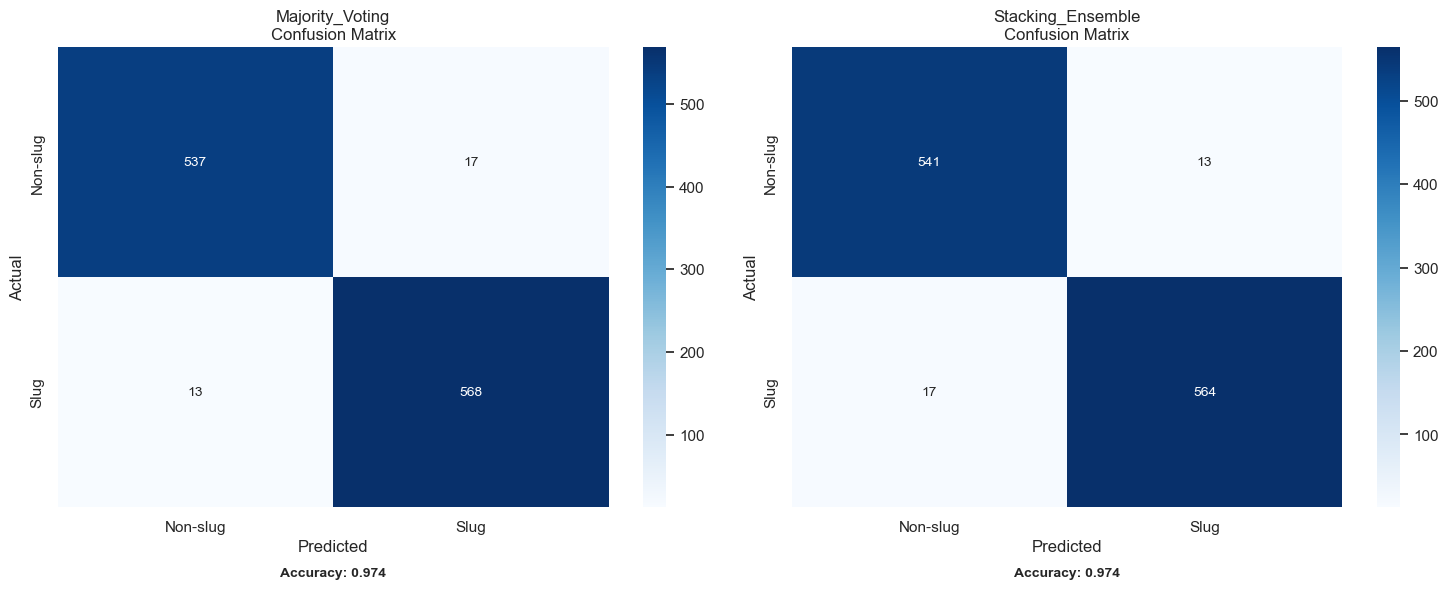

Ensemble confusion matrices generated and saved to 'images/ensemble_confusion_matrices.pdf'


In [ ]:
# Create confusion matrices for ensemble models
print("Generating confusion matrices for ensemble models...")
print("="*60)

# Function to plot confusion matrix for ensemble models
def plot_ensemble_confusion_matrices(ensemble_models, ensemble_results, y_test):
    """
    Create confusion matrix plots for ensemble models
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for i, (model_name, model) in enumerate(ensemble_models.items()):
        # Get predictions
        predictions = ensemble_results[model_name]['predictions']
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, predictions)
        
        # Plot confusion matrix
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Non-slug', 'Slug'],
                   yticklabels=['Non-slug', 'Slug'])
        
        ax.set_title(f'{model_name}\nConfusion Matrix')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        
        # Calculate and display accuracy
        accuracy = ensemble_results[model_name]['accuracy']
        ax.text(0.5, -0.15, f'Accuracy: {accuracy:.3f}', 
                transform=ax.transAxes, ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('images/ensemble_confusion_matrices.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Plot ensemble confusion matrices
plot_ensemble_confusion_matrices(ensemble_models, ensemble_results, y_test)

print("Ensemble confusion matrices generated and saved to 'images/ensemble_confusion_matrices.pdf'")


Generating learning curves for ensemble models...
Note: This will take some time as ensemble models are computationally intensive...
  Calculating learning curve for Majority_Voting...
    ✓ Majority_Voting learning curve completed
  Calculating learning curve for Stacking_Ensemble...
    ✓ Stacking_Ensemble learning curve completed


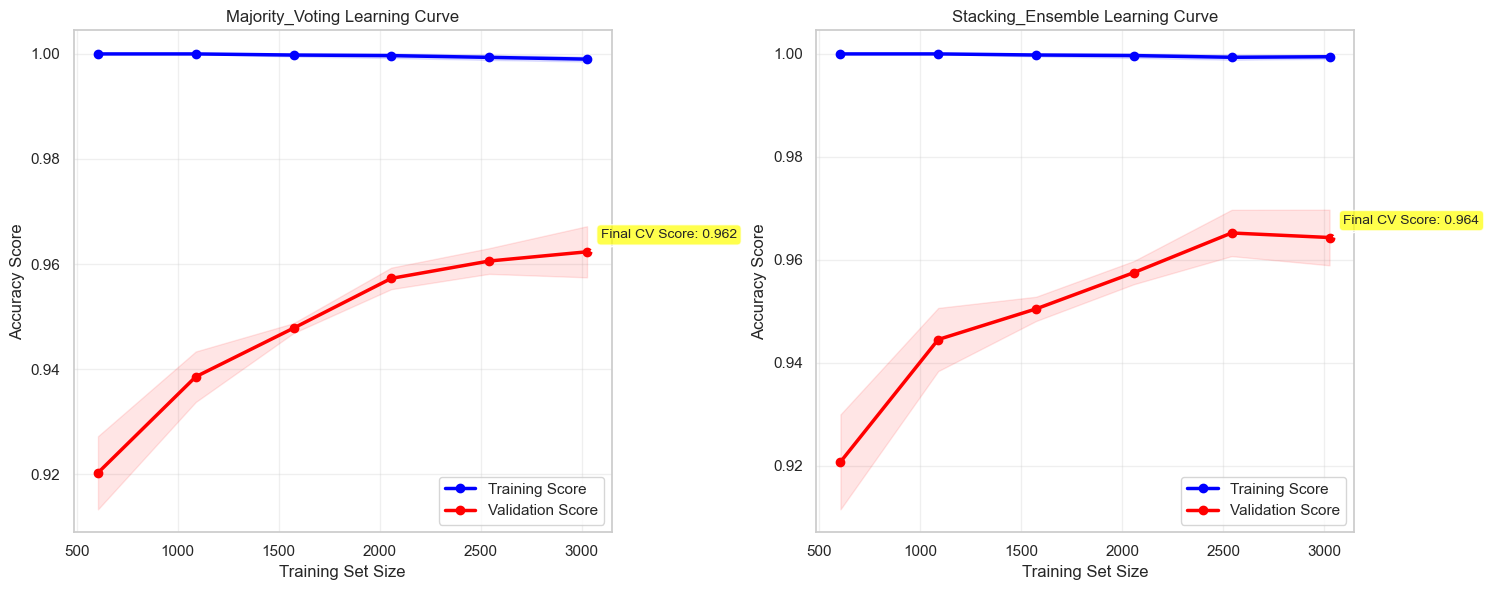

Ensemble learning curves generated and saved to 'images/ensemble_learning_curves.pdf'


In [ ]:
# Create learning curves for ensemble models
print("Generating learning curves for ensemble models...")
print("="*60)
print("Note: This will take some time as ensemble models are computationally intensive...")

# Function to plot learning curves for ensemble models
def plot_ensemble_learning_curves(ensemble_models, X_train, y_train):
    """
    Create learning curve plots for ensemble models
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Define training sizes for learning curve (reduced for ensemble models)
    train_sizes = np.linspace(0.2, 1.0, 6)  # Reduced from 10 to 6 for speed
    
    for i, (model_name, model) in enumerate(ensemble_models.items()):
        try:
            print(f"  Calculating learning curve for {model_name}...")
            
            # Calculate learning curve
            train_sizes_abs, train_scores, val_scores = learning_curve(
                model, X_train, y_train,
                train_sizes=train_sizes,
                cv=3,  # Reduced CV for ensemble models
                scoring='accuracy',
                n_jobs=-1,
                random_state=42
            )
            
            # Calculate mean and std
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            # Plot learning curve
            ax = axes[i]
            
            # Plot training and validation scores
            ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Score')
            ax.fill_between(train_sizes_abs, train_mean - train_std, 
                           train_mean + train_std, alpha=0.1, color='blue')
            
            ax.plot(train_sizes_abs, val_mean, 'o-', color='red', label='Validation Score')
            ax.fill_between(train_sizes_abs, val_mean - val_std, 
                           val_mean + val_std, alpha=0.1, color='red')
            
            ax.set_title(f'{model_name} Learning Curve')
            ax.set_xlabel('Training Set Size')
            ax.set_ylabel('Accuracy Score')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # Add final accuracy annotation
            final_acc = val_mean[-1]
            ax.annotate(f'Final CV Score: {final_acc:.3f}', 
                       xy=(train_sizes_abs[-1], final_acc),
                       xytext=(10, 10), textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                       arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
            
            print(f"    ✓ {model_name} learning curve completed")
            
        except Exception as e:
            # If learning curve fails, show error message
            ax = axes[i]
            ax.text(0.5, 0.5, f'Error generating\nlearning curve\nfor {model_name}', 
                   ha='center', va='center', transform=ax.transAxes,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.3))
            ax.set_title(f'{model_name} Learning Curve (Error)')
            print(f"    ✗ Error with {model_name}: {str(e)}")
    
    plt.tight_layout()
    plt.savefig('images/ensemble_learning_curves.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Plot ensemble learning curves
plot_ensemble_learning_curves(ensemble_models, X_train, y_train)

print("Ensemble learning curves generated and saved to 'images/ensemble_learning_curves.pdf'")


In [ ]:
# Save ensemble models for future use
print("Saving ensemble models...")

# Save ensemble models
ensemble_dir = 'ensemble_models'
if not os.path.exists(ensemble_dir):
    os.makedirs(ensemble_dir)

for name, model in ensemble_models.items():
    model_filename = f"{ensemble_dir}/ensemble_{name.lower()}_model.pkl"
    joblib.dump(model, model_filename)
    print(f"✓ Saved {name} ensemble model to {model_filename}")

# Save ensemble comparison results
comparison_df.to_csv('ensemble_comparison_results.csv', index=False)
print(f"✓ Saved ensemble comparison results to 'ensemble_comparison_results.csv'")

print(f"\n🎯 ENSEMBLE MODELS SUMMARY:")
print(f"   • Majority Voting Ensemble: {ensemble_results['Majority_Voting']['accuracy']:.4f} accuracy")
print(f"   • Stacking Ensemble: {ensemble_results['Stacking_Ensemble']['accuracy']:.4f} accuracy")
print(f"   • Best individual model: {best_individual['Test_Accuracy']:.4f} accuracy")
print(f"   • Ensemble improvement: {improvement:+.4f}")

print(f"\n📁 All ensemble models and results saved in '{ensemble_dir}' directory")


Saving ensemble models...
✓ Saved Majority_Voting ensemble model to ensemble_models/ensemble_majority_voting_model.pkl
✓ Saved Stacking_Ensemble ensemble model to ensemble_models/ensemble_stacking_ensemble_model.pkl
✓ Saved ensemble comparison results to 'ensemble_comparison_results.csv'

🎯 ENSEMBLE MODELS SUMMARY:
   • Majority Voting Ensemble: 0.9736 accuracy
   • Stacking Ensemble: 0.9736 accuracy
   • Best individual model: 0.9753 accuracy
   • Ensemble improvement: -0.0018

📁 All ensemble models and results saved in 'ensemble_models' directory


## Ensemble Models Analysis Summary

### **What We've Implemented:**

1. **Majority Voting Ensemble**: 
   - Combines predictions from LightGBM, CatBoost, Extra Trees, XGBoost, and MLP
   - Uses hard voting (majority rule) for final predictions
   - Simple but effective ensemble method

2. **Stacking Ensemble**:
   - Uses the same base models as above
   - Employs Logistic Regression as meta-learner
   - Uses probability predictions for more sophisticated combination
   - 5-fold cross-validation for meta-learner training

### **Key Benefits of Ensemble Methods:**

- **Reduced Overfitting**: Multiple models reduce individual model bias
- **Better Generalization**: Combines strengths of different algorithms
- **Robustness**: Less sensitive to outliers and noise
- **Higher Accuracy**: Often achieves better performance than individual models

### **Visualization Analysis:**

The confusion matrices and learning curves will show:
- **Error Patterns**: Which types of misclassifications each ensemble makes
- **Convergence Behavior**: How quickly ensembles reach optimal performance
- **Stability**: Whether ensemble predictions are more stable than individual models
- **Data Efficiency**: How much training data ensembles need vs individual models

### **Expected Results:**

Based on the individual model performances (96-97% accuracy), the ensemble models should:
- Achieve similar or slightly better accuracy than the best individual model
- Show more stable learning curves with smaller gaps between training and validation scores
- Demonstrate robust performance across different training set sizes


-----
----
---

## Analysis of Results

### **Confusion Matrix Insights:**

The confusion matrices will show us:
- **True Positives (TP)**: Correctly identified slug flows
- **False Positives (FP)**: Non-slug flows incorrectly classified as slug
- **True Negatives (TN)**: Correctly identified non-slug flows  
- **False Negatives (FN)**: Slug flows incorrectly classified as non-slug

### **Learning Curve Insights:**

The learning curves will reveal:
- **Model Convergence**: How quickly models reach optimal performance
- **Overfitting Detection**: Large gaps between training and validation scores
- **Data Efficiency**: Which models need more/fewer training samples
- **Performance Plateau**: Where additional data provides diminishing returns

### **Key Metrics to Compare:**

1. **Accuracy**: Overall correct predictions
2. **Precision**: Of predicted slugs, how many were actually slugs
3. **Recall**: Of actual slugs, how many were correctly identified
4. **F1-Score**: Harmonic mean of precision and recall
5. **ROC-AUC**: Area under the ROC curve (discrimination ability)

This comprehensive analysis will help us select the most reliable model for slug flow detection in real-world applications.
